# Dependencies and Imports

In [1]:
# Install required libraries
!pip install gymnasium highway-env stable-baselines3 torch matplotlib imageio sympy==1.12

# For video rendering
!apt-get install -y ffmpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 11.2 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: sympy
    Found existing installation: sympy 1.14.0
    Uninstalling sympy-1.14.0:
      Successfully uninstalled sympy-1.14.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.7.0+cu118 requires torch==2.7.0, but you have torch 2.4.1 which is incompatible.
suql 1.1.8 requires sympy>=1.14.0, but you have sympy 1.12 which is incompatible.
E: Could not open lock file /var/lib/dpkg/lock-frontend - open (13: Permission denied)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?


In [3]:
import gymnasium as gym
import highway_env
from stable_baselines3 import PPO
from tqdm import trange

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde

import torch
import imageio
# from google.colab import files
from IPython.display import Video

In [4]:
gym.register_envs(highway_env)

# Upload Model Zip File Here

In [5]:
uploaded = files.upload()

Saving final_model.zip to final_model.zip


# Verify Model has Low Probability of Failure

In [ ]:
NUM_EPISODES = 100
successes = 0
failures = 0

collision_positions = []  # (x, y) of ego at crash
collision_speeds = []     # ego speed at crash
collision_types = []      # 'merger' or 'highway'

model = PPO.load("final_model.zip")
env = gym.make("merge-v0", render_mode="rgb_array") # Added render_mode
device = model.device

for episode in trange(NUM_EPISODES):
    obs, info = env.reset()
    done = truncated = False
    merger = env.unwrapped.road.vehicles[-1]  # capture reference at reset, before any steps

    while not (done or truncated):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = env.step(action)

    vehicle = env.unwrapped.vehicle
    if getattr(vehicle, 'crashed', False):
        failures += 1
        collision_positions.append(vehicle.position.copy())
        collision_speeds.append(vehicle.speed)

        # If merger also crashed, they collided with each other
        hit_merger = merger.crashed
        collision_types.append('merger' if hit_merger else 'highway')
    else:
        successes += 1

env.close()

merger_fails  = collision_types.count('merger')
highway_fails = collision_types.count('highway')
p_fail = failures / NUM_EPISODES

print(f"Successes:      {successes}/{NUM_EPISODES}")
print(f"Failures:       {failures}/{NUM_EPISODES}")
print(f"  Merger:       {merger_fails} ({merger_fails/NUM_EPISODES*100:.2f}%)")
print(f"  Highway:      {highway_fails} ({highway_fails/NUM_EPISODES*100:.2f}%)")
print(f"P(failure) ≈    {p_fail:.4f}  ({p_fail*100:.2f}%)")

NameError: name 'PPO' is not defined

# Helper Functions: Run Rollout + Evaluate Proposal

In [18]:
def evaluate_proposal(random_prob = 0.01, NUM_EPISODES = 100):
    model = PPO.load("../merge/merge_ppo/PPO_1/final_model")
    env = gym.make("merge-v0", render_mode="rgb_array") # Added render_mode
    device = model.device

    failure_logps = []
    mlf_logp = -np.inf
    mlf_frames = None

    for episode in trange(NUM_EPISODES):
        failed, _, logp, _, frames = run_rollout(env, model, random_prob)
        if failed:
          failure_logps.append(logp)
          if logp > mlf_logp:
              mlf_logp = logp
              mlf_frames = frames

    env.close()

    return mlf_logp, mlf_frames, failure_logps


In [19]:
def run_rollout(env, model, random_prob=0.01, nominal_random_prob=0.01, record_video=False):

    obs, info = env.reset()
    done = truncated = False

    logp_nominal = 0.0
    logp_proposal = 0.0

    frames = []

    merger = env.unwrapped.road.vehicles[-1]

    n_actions = env.action_space.n

    while not (done or truncated):

        if record_video:
            frames.append(env.render())

        intended_action, _ = model.predict(obs, deterministic=True)

        # decide whether to inject random action
        random_action = np.random.rand() < random_prob

        if random_action:
            action = env.action_space.sample()
        else:
            action = intended_action

        # ---- proposal likelihood q ----
        if random_action:
            logp_proposal += np.log(random_prob) + np.log(1 / n_actions)
        else:
            logp_proposal += np.log(1 - random_prob)

        # ---- nominal likelihood p ----
        if random_action:
            logp_nominal += np.log(nominal_random_prob) + np.log(1 / n_actions)
        else:
            logp_nominal += np.log(1 - nominal_random_prob)

        obs, reward, done, truncated, info = env.step(action)

    vehicle = env.unwrapped.vehicle

    failed = False
    failure_type = None

    if getattr(vehicle, "crashed", False):
        failed = True
        hit_merger = merger.crashed
        failure_type = "merger" if hit_merger else "highway"

    return failed, failure_type, logp_nominal, logp_proposal, frames

# Fuzzing

In [ ]:
random_probabilities = np.array([0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.2, 0.5, 1.0])
num_rollouts_sweep = 50

action_metrics = {}
all_failure_logps = []
total_rollouts = 0
total_failures = 0

best_logp = -np.inf
best_frames = None
best_random_prob = None


for random_prob in random_probabilities:

    print(f"Testing random probability {random_prob:.2f}")

    metric, frames, failure_logps = evaluate_proposal(random_prob, num_rollouts_sweep)

    action_metrics[random_prob] = metric
    if len(failure_logps) > 0:
        all_failure_logps.extend(failure_logps)
    total_rollouts += num_rollouts_sweep
    total_failures += len(failure_logps)

    if metric > best_logp:
        best_logp = metric
        best_frames = frames
        best_random_prob = random_prob

    print("Number of failures for prob: ", random_prob, " is ", len(failure_logps))

print("\nTotal Rollouts:", total_rollouts)
print("Total Failures:", total_failures)
print("Highest Failure Likelihood:", best_logp)
print("Correponding Random Probability:", best_random_prob)

/home/jahall21/miniconda3/lib/python3.12/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Testing random probability 0.00


100%|██████████| 50/50 [00:09<00:00,  5.17it/s]
/home/jahall21/miniconda3/lib/python3.12/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Number of failures for prob:  0.0  is  0
Testing random probability 0.01


100%|██████████| 50/50 [00:09<00:00,  5.07it/s]

Number of failures for prob:  0.01  is  1

Total Rollouts: 100
Total Failures: 1
Highest Failure Likelihood: -0.14070470194902035
Correponding Random Probability: 0.01


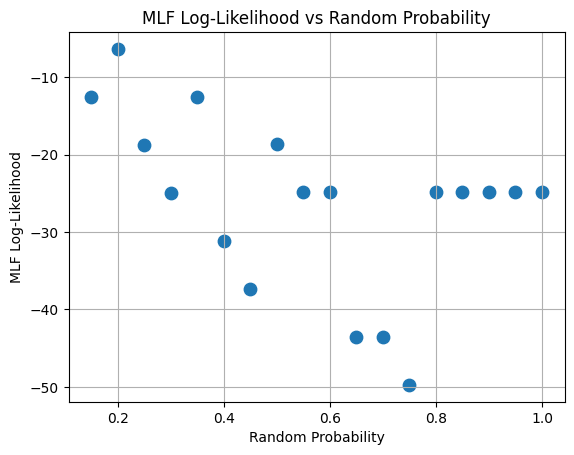

In [16]:
plt.figure()

plt.scatter(
    list(action_metrics.keys()),
    list(action_metrics.values()),
    s=80
)

plt.title("MLF Log-Likelihood vs Random Probability")
plt.xlabel("Random Probability")
plt.ylabel("MLF Log-Likelihood")

plt.grid(True)
plt.show()

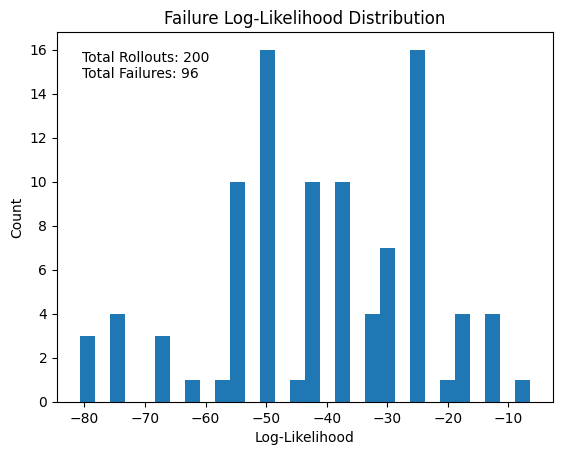

In [20]:
plt.figure()

plt.hist(all_failure_logps, bins=30)

plt.title("Failure Log-Likelihood Distribution")
plt.xlabel("Log-Likelihood")
plt.ylabel("Count")

plt.text(
    0.05, 0.95,
    f"Total Rollouts: {total_rollouts}\nTotal Failures: {total_failures}",
    transform=plt.gca().transAxes,
    verticalalignment='top'
)

plt.show()

In [21]:
if best_frames is not None:

    imageio.mimsave("most_likely_failure.mp4", best_frames, fps=30)

    print("\nMost Likely Failure Found")
    print("Random Probability:", best_random_prob)
    print("Log Likelihood:", best_logp)

else:
    print("No failures occurred during fuzzing.")


Most Likely Failure Found
Random Probability: 0.2
Log Likelihood: -6.35531280037121


In [22]:
Video("most_likely_failure.mp4", embed=True)

# Importance Sampling

In [23]:
NUM_ROLLOUTS = 100
random_prob = 0.2

model = PPO.load("final_model.zip")
env = gym.make("merge-v0", render_mode="rgb_array")

weights = []

pf_estimates = []
ci_lower = []
ci_upper = []

best_logp = -np.inf
best_frames = None

for i in trange(NUM_ROLLOUTS):

    failed, _, logp_nom, logp_prop, frames = run_rollout(
        env,
        model,
        random_prob
    )

    # importance weight
    if failed:
        w = np.exp(logp_nom - logp_prop)
    else:
        w = 0.0

    weights.append(w)

    weights_np = np.array(weights)

    pf_hat = np.mean(weights_np)
    pf_estimates.append(pf_hat)

    # 95% confidence interval
    if len(weights_np) > 1:
        std = np.std(weights_np, ddof=1)
        ci = 1.96 * std / np.sqrt(len(weights_np))
    else:
        ci = 0

    ci_lower.append(pf_hat - ci)
    ci_upper.append(pf_hat + ci)

    # track most likely failure
    if failed and logp_nom > best_logp:
        best_logp = logp_nom
        best_frames = frames

env.close()

  0%|          | 0/100 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
  1%|          | 1/100 [00:01<02:53,  1.75s/it]/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC)

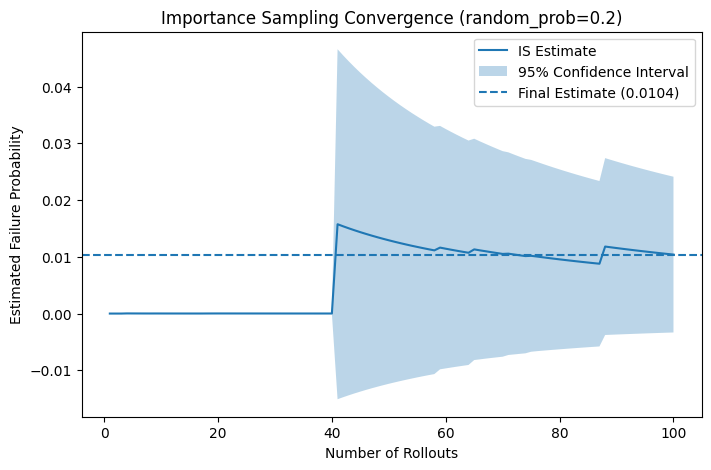

In [24]:
rollouts = np.arange(1, NUM_ROLLOUTS + 1)

plt.figure(figsize=(8,5))

# running estimate
plt.plot(rollouts, pf_estimates, label="IS Estimate")

# confidence interval
plt.fill_between(
    rollouts,
    ci_lower,
    ci_upper,
    alpha=0.3,
    label="95% Confidence Interval"
)

# final estimate line
plt.axhline(
    pf_estimates[-1],
    linestyle="--",
    label=f"Final Estimate ({pf_estimates[-1]:.4f})"
)

plt.xlabel("Number of Rollouts")
plt.ylabel("Estimated Failure Probability")
plt.title(f"Importance Sampling Convergence (random_prob={random_prob})")

plt.legend()
plt.show()

In [ ]:
if best_frames is not None:
    imageio.mimsave("most_likely_failure.mp4", best_frames, fps=30)